# 10 — DEM & Terrain Analysis: Phitsanulok
## Elevation → Profile → Slope → Hillshade → Aspect → Zonal Statistics

Notebook นี้ต่อจาก Notebook 09 ซึ่งเรียนรู้การสร้าง raster จาก vector points

Notebook 10 เริ่มจาก **Digital Elevation Model (DEM)** และถามว่า

> จาก elevation raster เราสามารถอธิบายรูปแบบภูมิประเทศและสรุปผลตามหน่วยการปกครองได้อย่างไร?

Workflow:

$$
\boxed{
DEM
\rightarrow
Inspect
\rightarrow
Visualize
\rightarrow
Clip
\rightarrow
Profile
\rightarrow
Slope
\rightarrow
Hillshade
\rightarrow
Aspect
\rightarrow
Zonal\ Statistics
}
$$

## Learning objectives

เมื่อเรียนจบ นิสิตควรสามารถ

1. ตรวจ CRS, pixel size, dimensions, transform, bounds, NoData และ DEM range
2. Render elevation raster ด้วย color scale ที่เหมาะสม
3. Overlay DEM กับขอบเขตประเทศไทยและจังหวัด
4. Clip DEM ด้วยขอบเขตจังหวัดพิษณุโลก
5. Reproject DEM ไป projected CRS ก่อน terrain analysis
6. สร้าง elevation profiles 8 ทิศทางจาก geometric centroid
7. คำนวณ slope และสรุปสถิติ
8. สร้าง hillshade และ DEM–hillshade composite
9. คำนวณ aspect และจัดเป็น 8 compass classes
10. อธิบายว่า aspect เป็น circular variable
11. ทำ slope zonal statistics รายตำบล
12. ทำ Folium choropleth สำหรับ Mean / Median / P90 slope
13. ใช้ boxplot เปรียบเทียบ slope distribution ของตำบลภายในอำเภอ

## DEM concept

DEM คือ raster ที่แต่ละ pixel เก็บ elevation:

$$
DEM(x,y)=z
$$

DEM ยังไม่ใช่ slope, aspect หรือ hillshade

สิ่งเหล่านั้นเป็น **terrain derivatives** ที่คำนวณจากการเปลี่ยนแปลง elevation รอบ pixel

## หลักสำคัญก่อนเริ่ม

อย่าเริ่มจากการ plot อย่างเดียว

ก่อนวิเคราะห์ raster ต้องตรวจ:

```text
CRS
Pixel size
Rows / Columns
Transform
Bounds
NoData
Data type
Value range
```

และสำหรับ slope:

> horizontal unit และ vertical unit ต้องเข้ากัน

# Part A — Setup

## 1. Install and import libraries

In [1]:
%pip -q install geopandas rasterio folium xyzservices pyogrio branca

In [2]:
from pathlib import Path
import shutil
import zipfile
import json

import requests
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch

import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import geometry_mask
from rasterio.transform import array_bounds

from shapely.geometry import Point, LineString, MultiLineString, GeometryCollection, mapping

import folium
import xyzservices.providers as xyz
import branca.colormap as bcm

from IPython.display import display

print("GeoPandas:", gpd.__version__)
print("Rasterio :", rasterio.__version__)
print("Folium   :", folium.__version__)

GeoPandas: 1.2.0
Rasterio : 1.5.2
Folium   : 0.20.0


## 2. Thai font + workspace

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    r = requests.get(FONT_URL, timeout=60)
    r.raise_for_status()
    FONT_FILE.write_bytes(r.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))
font_name = mpl.font_manager.FontProperties(fname=str(FONT_FILE)).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("/content/gis10_data")
OUTPUT_DIR = Path("/content/gis10_outputs")
RASTER_DIR = OUTPUT_DIR / "rasters"
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [DATA_DIR, RASTER_DIR, MAP_DIR, VECTOR_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Thai font:", font_name)
print("Output   :", OUTPUT_DIR)

Thai font: Sarabun
Output   : /content/gis10_outputs


## 3. Download / field helpers

In [4]:
def download_file(url, output_path):
    output_path = Path(output_path)

    if not output_path.exists():
        r = requests.get(url, timeout=180)
        r.raise_for_status()
        output_path.write_bytes(r.content)

    return output_path


def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        zip_path.write_bytes(r.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(f"ไม่พบ .shp ใน {zip_name}")

    return shp_files[0]


def find_column(gdf, candidates, required=False):
    lookup = {str(c).upper(): c for c in gdf.columns}

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError("ไม่พบ field: " + ", ".join(candidates))

    return None

# Part B — Download & Inspect DEM

## 4. Download instructor DEM

ไฟล์:

```text
https://github.com/nattaponm/Teach_GIS_Python_Colab/blob/main/data/wrl_dem_phk1.tif
```

ใช้ raw URL เพื่อดาวน์โหลด GeoTIFF โดยตรง

In [5]:
DEM_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/Teach_GIS_Python_Colab/"
    "main/data/wrl_dem_phk1.tif"
)

DEM_PATH = download_file(
    DEM_URL,
    DATA_DIR / "wrl_dem_phk1.tif"
)

print("DEM:", DEM_PATH)
print(f"File size: {DEM_PATH.stat().st_size / 1024 / 1024:,.2f} MB")

DEM: /content/gis10_data/wrl_dem_phk1.tif
File size: 1.75 MB


## 5. Inspect raster metadata

In [6]:
with rasterio.open(DEM_PATH) as src:
    dem_crs = src.crs
    dem_transform = src.transform
    dem_bounds = src.bounds
    dem_width = src.width
    dem_height = src.height
    dem_count = src.count
    dem_dtype = src.dtypes[0]
    dem_nodata = src.nodata
    dem_res = src.res

metadata_table = pd.DataFrame({
    "Property": [
        "CRS",
        "Width (pixels)",
        "Height (pixels)",
        "Band count",
        "Pixel width",
        "Pixel height",
        "Data type",
        "NoData",
        "Left",
        "Bottom",
        "Right",
        "Top"
    ],
    "Value": [
        str(dem_crs),
        dem_width,
        dem_height,
        dem_count,
        dem_res[0],
        dem_res[1],
        dem_dtype,
        dem_nodata,
        dem_bounds.left,
        dem_bounds.bottom,
        dem_bounds.right,
        dem_bounds.top
    ]
})

display(metadata_table)

print("\nAffine transform:")
print(dem_transform)

,Property,Value
0,CRS,EPSG:4326
1,Width (pixels),904
2,Height (pixels),870
3,Band count,1
4,Pixel width,0.005
5,Pixel height,0.005
6,Data type,int16
7,NoData,32767.0
8,Left,97.95625
9,Bottom,14.60125



Affine transform:
| 0.00, 0.00, 97.96|
| 0.00,-0.01, 18.95|
| 0.00, 0.00, 1.00|


## 6. Read DEM and remove NoData from statistics

In [7]:
with rasterio.open(DEM_PATH) as src:
    dem_ma = src.read(1, masked=True)

dem = dem_ma.astype("float32").filled(np.nan)

valid_dem = dem[np.isfinite(dem)]

print(f"All pixels    : {dem.size:,}")
print(f"Valid pixels  : {len(valid_dem):,}")
print(f"Masked/NoData : {dem.size - len(valid_dem):,}")

All pixels    : 786,480
Valid pixels  : 786,462
Masked/NoData : 18


## 7. Elevation statistics

In [8]:
dem_stats = pd.DataFrame({
    "Statistic": [
        "Minimum", "P10", "P25", "Mean", "Median",
        "P75", "P90", "Maximum", "Standard deviation"
    ],
    "Elevation_m": [
        np.nanmin(valid_dem),
        np.nanpercentile(valid_dem, 10),
        np.nanpercentile(valid_dem, 25),
        np.nanmean(valid_dem),
        np.nanmedian(valid_dem),
        np.nanpercentile(valid_dem, 75),
        np.nanpercentile(valid_dem, 90),
        np.nanmax(valid_dem),
        np.nanstd(valid_dem)
    ]
})

display(dem_stats.round(2))

,Statistic,Elevation_m
0,Minimum,-3.000000
1,P10,46.000000
2,P25,134.000000
3,Mean,371.579987
4,Median,278.000000
5,P75,538.000000
6,P90,838.000000
7,Maximum,2558.000000
8,Standard deviation,313.160004


### Actual range vs display range

รายงาน min–max จริงจากข้อมูล

แต่แผนที่อาจ render ด้วย P1–P99 เพื่อเพิ่ม contrast

$$
\boxed{
Visualization\ scale
\neq
Actual\ data\ range
}
$$

# Part C — DEM in Geographic Context

## 8. Load province boundaries

In [9]:
BASE_GIS = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/main"
)

ADM1_URL = (
    f"{BASE_GIS}/tha_adm1/"
    "tha_adm1_province_shapefile.zip"
)

adm1_shp = download_and_extract_zip(
    ADM1_URL,
    "tha_adm1_province_shapefile.zip",
    "adm1"
)

province = gpd.read_file(adm1_shp, encoding="UTF-8")

P_CODE = find_column(
    province,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

P_NAME = find_column(
    province,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

print("Province CRS:", province.crs)
print("DEM CRS     :", dem_crs)

Province CRS: EPSG:4326
DEM CRS     : EPSG:4326


## 9. Match vector CRS to DEM CRS

In [10]:
province_dem_crs = province.to_crs(dem_crs)

thailand_dem_crs = (
    province_dem_crs[["geometry"]]
    .dissolve()
    .reset_index(drop=True)
)

print("Overlay CRS:", province_dem_crs.crs)

Overlay CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


## 10. Plot DEM + Thailand + Province boundaries

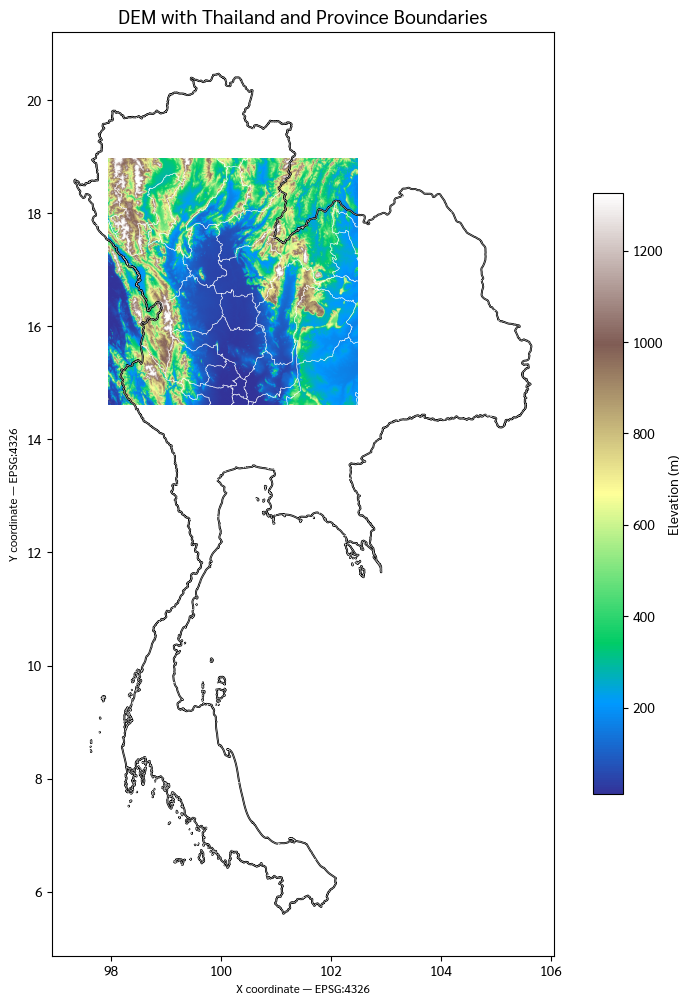

In [11]:
DEM_VMIN = np.nanpercentile(valid_dem, 1)
DEM_VMAX = np.nanpercentile(valid_dem, 99)

fig_dem_overview, ax = plt.subplots(figsize=(10, 12))

im = ax.imshow(
    dem,
    extent=[
        dem_bounds.left,
        dem_bounds.right,
        dem_bounds.bottom,
        dem_bounds.top
    ],
    origin="upper",
    cmap="terrain",
    vmin=DEM_VMIN,
    vmax=DEM_VMAX
)

thailand_dem_crs.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.4
)

province_dem_crs.boundary.plot(
    ax=ax,
    color="white",
    linewidth=0.35,
    alpha=0.85
)

cbar = fig_dem_overview.colorbar(im, ax=ax, shrink=0.65)
cbar.set_label("Elevation (m)")

ax.set_title(
    "DEM with Thailand and Province Boundaries",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(f"X coordinate — {dem_crs}")
ax.set_ylabel(f"Y coordinate — {dem_crs}")

plt.show()

## 11. What should we inspect?

ก่อนตัดพิษณุโลก ให้ตรวจด้วยสายตา:

- DEM coverage ครอบคลุมพื้นที่ที่ต้องการหรือไม่?
- มี NoData holes หรือไม่?
- lowland / highland pattern สมเหตุสมผลหรือไม่?
- provincial boundaries align กับ raster หรือไม่?

# Part D — Clip DEM to Phitsanulok

## 12. Select Phitsanulok

In [12]:
phs = province[
    province[P_NAME]
    .astype(str)
    .str.contains("พิษณุโลก", na=False)
].copy()

if len(phs) != 1:
    raise ValueError(
        f"Expected 1 Phitsanulok feature, found {len(phs)}"
    )

display(phs[[P_CODE, P_NAME]])

,ADM1_PCODE,ADM1_TH
52,TH65,พิษณุโลก


## 13. Clip DEM with Phitsanulok polygon

In [13]:
phs_dem_crs = phs.to_crs(dem_crs)

geoms = [mapping(g) for g in phs_dem_crs.geometry]

with rasterio.open(DEM_PATH) as src:
    clipped_ma, clipped_transform = mask(
        src,
        geoms,
        crop=True,
        filled=False
    )
    clipped_profile = src.profile.copy()

phs_dem = clipped_ma[0].astype("float32").filled(np.nan)

clipped_profile.update({
    "height": phs_dem.shape[0],
    "width": phs_dem.shape[1],
    "transform": clipped_transform
})

print("Clipped raster shape:", phs_dem.shape)

Clipped raster shape: (286, 252)


## 14. Render clipped DEM

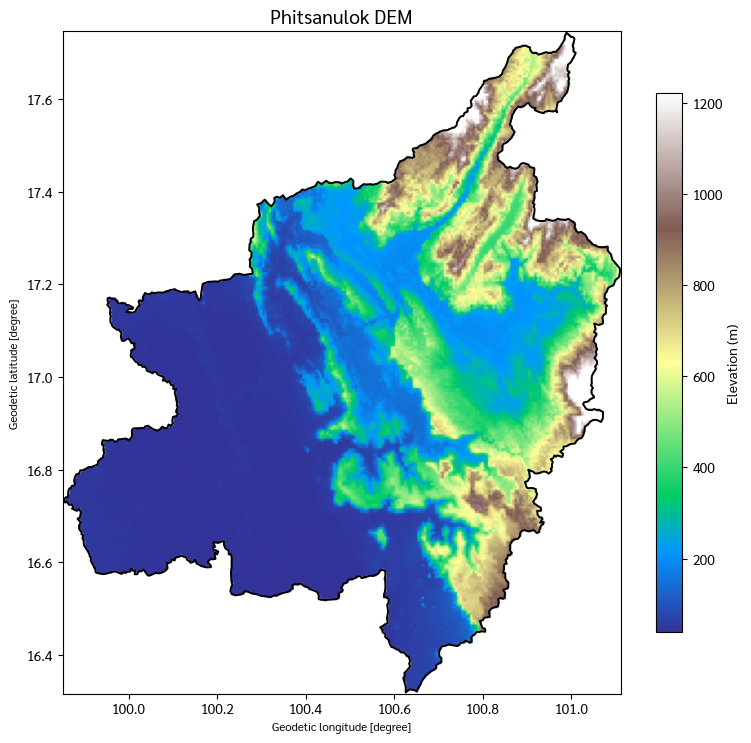

In [14]:
phs_bounds_original = array_bounds(
    phs_dem.shape[0],
    phs_dem.shape[1],
    clipped_transform
)

phs_valid = phs_dem[np.isfinite(phs_dem)]

PHS_VMIN = np.nanpercentile(phs_valid, 1)
PHS_VMAX = np.nanpercentile(phs_valid, 99)

fig_phs_dem, ax = plt.subplots(figsize=(9, 10))

im = ax.imshow(
    phs_dem,
    extent=[
        phs_bounds_original[0],
        phs_bounds_original[2],
        phs_bounds_original[1],
        phs_bounds_original[3]
    ],
    origin="upper",
    cmap="terrain",
    vmin=PHS_VMIN,
    vmax=PHS_VMAX
)

phs_dem_crs.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.4
)

fig_phs_dem.colorbar(
    im,
    ax=ax,
    shrink=0.7,
    label="Elevation (m)"
)

ax.set_title(
    "Phitsanulok DEM",
    fontsize=14,
    fontweight="bold"
)

plt.show()

## 15. Statistics of clipped DEM

In [15]:
phs_dem_stats = pd.DataFrame({
    "Statistic": [
        "Valid pixels", "Minimum", "P10", "P25",
        "Mean", "Median", "P75", "P90",
        "Maximum", "Standard deviation"
    ],
    "Value": [
        len(phs_valid),
        np.nanmin(phs_valid),
        np.nanpercentile(phs_valid, 10),
        np.nanpercentile(phs_valid, 25),
        np.nanmean(phs_valid),
        np.nanmedian(phs_valid),
        np.nanpercentile(phs_valid, 75),
        np.nanpercentile(phs_valid, 90),
        np.nanmax(phs_valid),
        np.nanstd(phs_valid)
    ]
})

display(phs_dem_stats.round(2))

,Statistic,Value
0,Valid pixels,35714.00
1,Minimum,30.00
2,P10,43.00
3,P25,49.00
4,Mean,301.07
5,Median,208.00
6,P75,471.00
7,P90,754.00
8,Maximum,2049.00
9,Standard deviation,299.06


## 16. Save clipped DEM

In [16]:
PHS_DEM_ORIGINAL = RASTER_DIR / "phitsanulok_dem_original_crs.tif"

out = np.where(
    np.isfinite(phs_dem),
    phs_dem,
    -9999.0
).astype("float32")

profile = clipped_profile.copy()

profile.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999.0,
    "compress": "deflate"
})

with rasterio.open(PHS_DEM_ORIGINAL, "w", **profile) as dst:
    dst.write(out, 1)

print("Saved:", PHS_DEM_ORIGINAL)

Saved: /content/gis10_outputs/rasters/phitsanulok_dem_original_crs.tif


# Part E — Reproject DEM for Terrain Analysis

## 17. Why reproject?

Slope uses elevation change per horizontal distance.

If DEM coordinates are degrees but elevation is meters, the units are incompatible.

For local analysis we use:

```text
EPSG:32647
WGS 84 / UTM zone 47N
```

$$
\boxed{
Horizontal\ and\ vertical\ units\ must\ be\ compatible
}
$$

## 18. Reproject clipped DEM to EPSG:32647

In [17]:
TARGET_CRS = "EPSG:32647"

with rasterio.open(PHS_DEM_ORIGINAL) as src:
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs,
        TARGET_CRS,
        src.width,
        src.height,
        *src.bounds
    )

    src_arr = src.read(1)

    dem_utm_raw = np.full(
        (dst_height, dst_width),
        -9999.0,
        dtype="float32"
    )

    reproject(
        source=src_arr,
        destination=dem_utm_raw,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src.nodata,
        dst_transform=dst_transform,
        dst_crs=TARGET_CRS,
        dst_nodata=-9999.0,
        resampling=Resampling.bilinear
    )

dem_utm = dem_utm_raw.astype("float32")
dem_utm[dem_utm == -9999.0] = np.nan

PHS_DEM_UTM = RASTER_DIR / "phitsanulok_dem_utm47n.tif"

with rasterio.open(
    PHS_DEM_UTM,
    "w",
    driver="GTiff",
    height=dst_height,
    width=dst_width,
    count=1,
    dtype="float32",
    crs=TARGET_CRS,
    transform=dst_transform,
    nodata=-9999.0,
    compress="deflate"
) as dst:
    dst.write(
        np.where(np.isfinite(dem_utm), dem_utm, -9999.0).astype("float32"),
        1
    )

print("Saved:", PHS_DEM_UTM)

Saved: /content/gis10_outputs/rasters/phitsanulok_dem_utm47n.tif


## 19. Inspect projected pixel size

In [18]:
xres = abs(dst_transform.a)
yres = abs(dst_transform.e)

print("Analysis CRS    :", TARGET_CRS)
print("Pixel width (m) :", xres)
print("Pixel height (m):", yres)
print("Shape           :", dem_utm.shape)

utm_bounds = array_bounds(
    dem_utm.shape[0],
    dem_utm.shape[1],
    dst_transform
)

Analysis CRS    : EPSG:32647
Pixel width (m) : 544.2190495269591
Pixel height (m): 544.2190495269591
Shape           : (293, 249)


# Part F — Eight-direction Terrain Profiles

## 20. Profile origin and directions

ใช้ geometric centroid ของจังหวัดเป็น reference

```text
N, NE, E, SE, S, SW, W, NW
```

> Geometric centroid ≠ city center

In [19]:
phs_utm = phs.to_crs(TARGET_CRS)
phs_geom = phs_utm.geometry.iloc[0]
center = phs_geom.centroid

print("Centroid X:", center.x)
print("Centroid Y:", center.y)

Centroid X: 664442.2911784638
Centroid Y: 1878086.845937863


## 21. Build and clip 8 radial profile lines

In [20]:
direction_angles = {
    "N": 90,
    "NE": 45,
    "E": 0,
    "SE": -45,
    "S": -90,
    "SW": -135,
    "W": 180,
    "NW": 135
}

xmin, ymin, xmax, ymax = phs_utm.total_bounds
max_ray = np.hypot(xmax - xmin, ymax - ymin) * 1.5


def choose_origin_segment(geom, origin_point):
    if geom.is_empty:
        return None

    if isinstance(geom, LineString):
        parts = [geom]
    elif isinstance(geom, MultiLineString):
        parts = list(geom.geoms)
    elif isinstance(geom, GeometryCollection):
        parts = [
            g for g in geom.geoms
            if isinstance(g, LineString)
        ]
    else:
        parts = []

    if not parts:
        return None

    parts = sorted(
        parts,
        key=lambda g: (g.distance(origin_point), -g.length)
    )

    line = parts[0]

    p0 = Point(line.coords[0])
    p1 = Point(line.coords[-1])

    if p0.distance(origin_point) > p1.distance(origin_point):
        line = LineString(list(line.coords)[::-1])

    return line


profile_rows = []

for direction, angle in direction_angles.items():
    theta = np.deg2rad(angle)

    endpoint = Point(
        center.x + max_ray * np.cos(theta),
        center.y + max_ray * np.sin(theta)
    )

    ray = LineString([center, endpoint])
    clipped = ray.intersection(phs_geom)
    line = choose_origin_segment(clipped, center)

    if line is not None:
        profile_rows.append({
            "direction": direction,
            "geometry": line
        })

profiles_gdf = gpd.GeoDataFrame(
    profile_rows,
    geometry="geometry",
    crs=TARGET_CRS
)

display(profiles_gdf[["direction"]])

,direction
0,N
1,NE
2,E
3,SE
4,S
5,SW
6,W
7,NW


## 22. Map profile directions on DEM

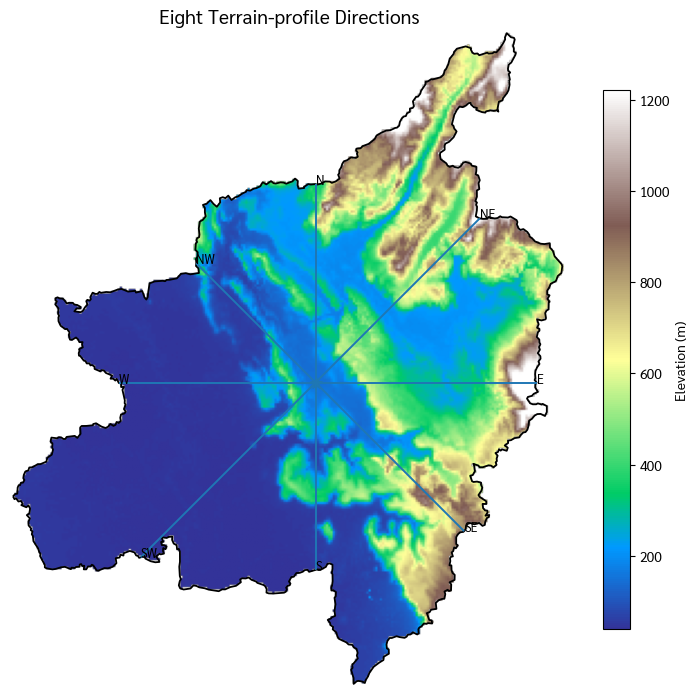

In [21]:
fig_profile_map, ax = plt.subplots(figsize=(9, 10))

im = ax.imshow(
    dem_utm,
    extent=[
        utm_bounds[0],
        utm_bounds[2],
        utm_bounds[1],
        utm_bounds[3]
    ],
    origin="upper",
    cmap="terrain",
    vmin=PHS_VMIN,
    vmax=PHS_VMAX
)

phs_utm.boundary.plot(ax=ax, color="black", linewidth=1.3)
profiles_gdf.plot(ax=ax, linewidth=1.4)

gpd.GeoSeries([center], crs=TARGET_CRS).plot(
    ax=ax,
    markersize=70,
    marker="*"
)

for _, row in profiles_gdf.iterrows():
    end_point = Point(row.geometry.coords[-1])

    ax.text(
        end_point.x,
        end_point.y,
        row["direction"],
        fontsize=9,
        fontweight="bold"
    )

fig_profile_map.colorbar(
    im,
    ax=ax,
    shrink=0.7,
    label="Elevation (m)"
)

ax.set_title(
    "Eight Terrain-profile Directions",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

## 23. Sample elevation along each line

In [22]:
PROFILE_STEP_M = max(
    30.0,
    min(xres, yres)
)


def sample_profile(raster_path, line, step_m):
    distances = np.arange(
        0,
        line.length + step_m,
        step_m
    )

    points = [
        line.interpolate(min(d, line.length))
        for d in distances
    ]

    coords = [(p.x, p.y) for p in points]

    with rasterio.open(raster_path) as src:
        values = np.array([
            v[0] for v in src.sample(coords)
        ], dtype=float)

        if src.nodata is not None:
            values[values == src.nodata] = np.nan

    return pd.DataFrame({
        "distance_km": distances / 1000,
        "elevation_m": values
    })


profile_tables = []

for _, row in profiles_gdf.iterrows():
    tmp = sample_profile(
        PHS_DEM_UTM,
        row.geometry,
        PROFILE_STEP_M
    )

    tmp["direction"] = row["direction"]
    profile_tables.append(tmp)

profile_df = pd.concat(
    profile_tables,
    ignore_index=True
)

display(profile_df.head(10))

,distance_km,elevation_m,direction
0,0.000000,149.276901,N
1,0.544219,148.855453,N
2,1.088438,148.302933,N
3,1.632657,147.166000,N
4,2.176876,146.865738,N
5,2.721095,145.852661,N
6,3.265314,147.127243,N
7,3.809533,148.896759,N
8,4.353752,149.041092,N
9,4.897971,155.863922,N


## 24. Plot all 8 profiles

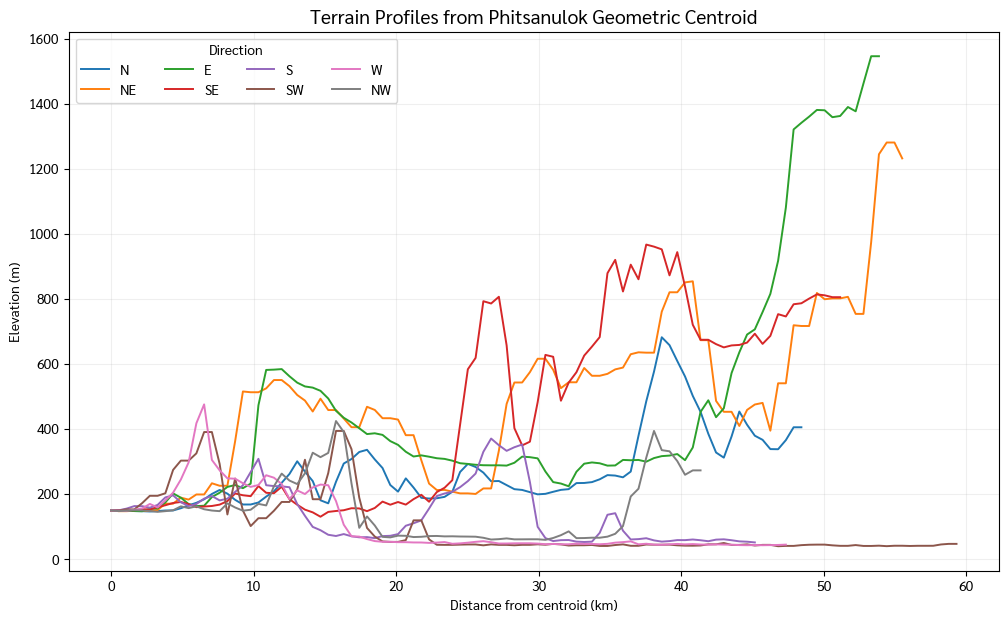

In [23]:
fig_profiles, ax = plt.subplots(figsize=(12, 7))

for direction in direction_angles:
    subset = profile_df[
        profile_df["direction"] == direction
    ]

    ax.plot(
        subset["distance_km"],
        subset["elevation_m"],
        label=direction,
        linewidth=1.4
    )

ax.set_title(
    "Terrain Profiles from Phitsanulok Geometric Centroid",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Distance from centroid (km)")
ax.set_ylabel("Elevation (m)")
ax.grid(alpha=0.2)
ax.legend(title="Direction", ncol=4)

plt.show()

## 25. Profile interpretation

ถามจากกราฟ:

- ทิศใด elevation เพิ่มเร็วที่สุด?
- ทิศใดค่อนข้างราบ?
- ทิศใดมี relief สูง?
- terrain transition เกิดที่ระยะประมาณเท่าใด?

# Part G — Slope

## 26. Slope equation

$$
Slope
=
\tan^{-1}
\left[
\sqrt{
\left(\frac{\partial z}{\partial x}\right)^2+
\left(\frac{\partial z}{\partial y}\right)^2
}
\right]
$$

บทนี้ใช้หน่วย **degrees**

## 27. Calculate slope

In [24]:
dz_drow, dz_dcol = np.gradient(dem_utm)

# x increases east
dz_dx = dz_dcol / xres

# raster row increases south, but UTM y increases north
dz_dy = -dz_drow / yres

slope_rad = np.arctan(
    np.hypot(dz_dx, dz_dy)
)

slope_deg = np.degrees(slope_rad)

slope_deg[~np.isfinite(dem_utm)] = np.nan

## 28. Slope statistics

In [25]:
slope_valid = slope_deg[np.isfinite(slope_deg)]

slope_stats = pd.DataFrame({
    "Statistic": [
        "Minimum", "P25", "Mean", "Median",
        "P75", "P90", "Maximum", "Standard deviation"
    ],
    "Slope_degree": [
        np.nanmin(slope_valid),
        np.nanpercentile(slope_valid, 25),
        np.nanmean(slope_valid),
        np.nanmedian(slope_valid),
        np.nanpercentile(slope_valid, 75),
        np.nanpercentile(slope_valid, 90),
        np.nanmax(slope_valid),
        np.nanstd(slope_valid)
    ]
})

display(slope_stats.round(2))

,Statistic,Slope_degree
0,Minimum,0.000000
1,P25,0.180000
2,Mean,3.140000
3,Median,1.340000
4,P75,4.870000
5,P90,9.040000
6,Maximum,27.959999
7,Standard deviation,4.000000


## 29. Render slope

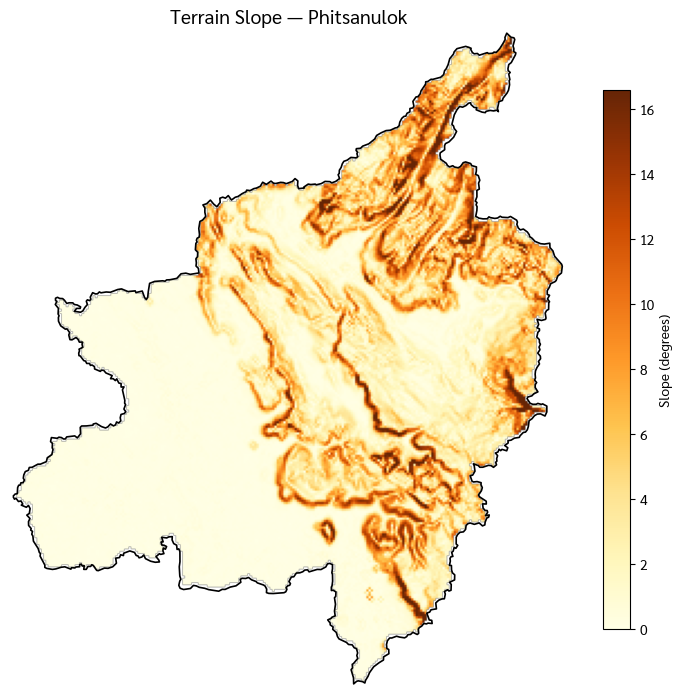

In [26]:
SLOPE_VMAX = np.nanpercentile(slope_valid, 99)

fig_slope, ax = plt.subplots(figsize=(9, 10))

im = ax.imshow(
    slope_deg,
    extent=[
        utm_bounds[0],
        utm_bounds[2],
        utm_bounds[1],
        utm_bounds[3]
    ],
    origin="upper",
    cmap="YlOrBr",
    vmin=0,
    vmax=SLOPE_VMAX
)

phs_utm.boundary.plot(ax=ax, color="black", linewidth=1.2)

fig_slope.colorbar(
    im,
    ax=ax,
    shrink=0.7,
    label="Slope (degrees)"
)

ax.set_title(
    "Terrain Slope — Phitsanulok",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

## 30. Raster export helper + save slope

In [27]:
def write_float_raster(
    path,
    array,
    transform,
    crs,
    nodata=-9999.0
):
    out = np.where(
        np.isfinite(array),
        array,
        nodata
    ).astype("float32")

    with rasterio.open(
        path,
        "w",
        driver="GTiff",
        height=out.shape[0],
        width=out.shape[1],
        count=1,
        dtype="float32",
        crs=crs,
        transform=transform,
        nodata=nodata,
        compress="deflate"
    ) as dst:
        dst.write(out, 1)


SLOPE_PATH = RASTER_DIR / "phitsanulok_slope_deg.tif"

write_float_raster(
    SLOPE_PATH,
    slope_deg,
    dst_transform,
    TARGET_CRS
)

print("Saved:", SLOPE_PATH)

Saved: /content/gis10_outputs/rasters/phitsanulok_slope_deg.tif


# Part H — Hillshade

## 31. Hillshade concept

Hillshade จำลองแสงตกกระทบบน terrain

ใช้:

```text
Sun azimuth = 315°
Sun altitude = 45°
```

> **Hillshade is visualization, not elevation**

## 32. Calculate hillshade

In [28]:
SUN_AZIMUTH = 315.0
SUN_ALTITUDE = 45.0

aspect_rad_for_hs = (
    np.arctan2(-dz_dx, -dz_dy)
    % (2 * np.pi)
)

az_rad = np.deg2rad(SUN_AZIMUTH)
alt_rad = np.deg2rad(SUN_ALTITUDE)

illumination = (
    np.sin(alt_rad) * np.cos(slope_rad)
    +
    np.cos(alt_rad)
    * np.sin(slope_rad)
    * np.cos(az_rad - aspect_rad_for_hs)
)

hillshade = np.clip(
    illumination,
    0,
    1
) * 255

hillshade[~np.isfinite(dem_utm)] = np.nan

## 33. Plot hillshade

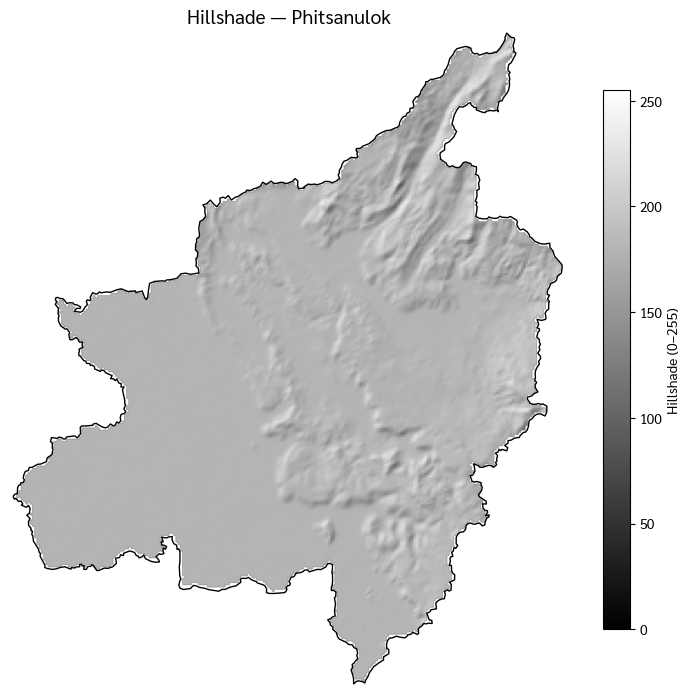

In [29]:
fig_hillshade, ax = plt.subplots(figsize=(9, 10))

im = ax.imshow(
    hillshade,
    extent=[
        utm_bounds[0],
        utm_bounds[2],
        utm_bounds[1],
        utm_bounds[3]
    ],
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=255
)

phs_utm.boundary.plot(ax=ax, color="black", linewidth=1.0)

fig_hillshade.colorbar(
    im,
    ax=ax,
    shrink=0.7,
    label="Hillshade (0–255)"
)

ax.set_title(
    "Hillshade — Phitsanulok",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

## 34. DEM + Hillshade composite

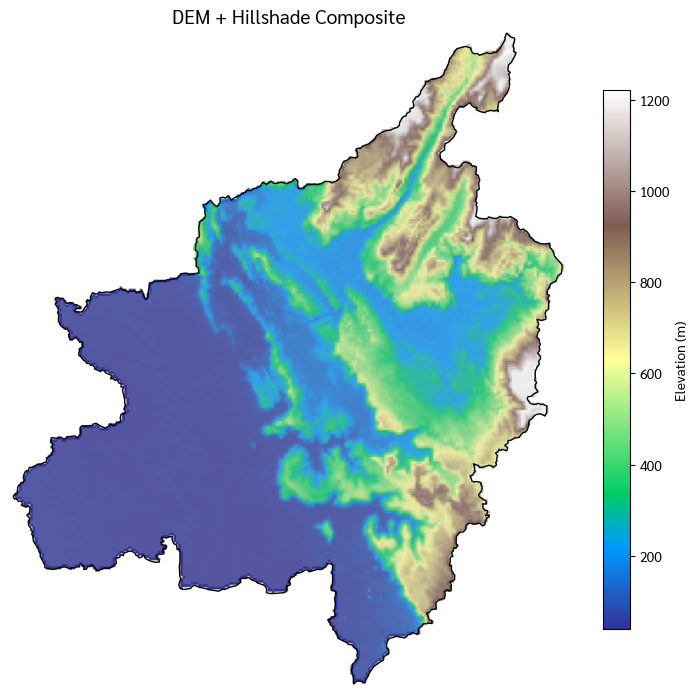

In [30]:
fig_dem_hs, ax = plt.subplots(figsize=(9, 10))

dem_layer = ax.imshow(
    dem_utm,
    extent=[
        utm_bounds[0],
        utm_bounds[2],
        utm_bounds[1],
        utm_bounds[3]
    ],
    origin="upper",
    cmap="terrain",
    vmin=PHS_VMIN,
    vmax=PHS_VMAX
)

ax.imshow(
    hillshade,
    extent=[
        utm_bounds[0],
        utm_bounds[2],
        utm_bounds[1],
        utm_bounds[3]
    ],
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=255,
    alpha=0.28
)

phs_utm.boundary.plot(ax=ax, color="black", linewidth=1.0)

fig_dem_hs.colorbar(
    dem_layer,
    ax=ax,
    shrink=0.7,
    label="Elevation (m)"
)

ax.set_title(
    "DEM + Hillshade Composite",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

## 35. Export hillshade

In [31]:
HILLSHADE_PATH = RASTER_DIR / "phitsanulok_hillshade.tif"

write_float_raster(
    HILLSHADE_PATH,
    hillshade,
    dst_transform,
    TARGET_CRS
)

print("Saved:", HILLSHADE_PATH)

Saved: /content/gis10_outputs/rasters/phitsanulok_hillshade.tif


# Part I — Aspect

## 36. Aspect is directional

```text
0° / 360° = N
90°        = E
180°       = S
270°       = W
```

Aspect เป็น **circular variable**

เช่น 1° และ 359° อยู่ใกล้กันมาก แม้ arithmetic mean จะให้ 180°

$$
\boxed{
Circular\ variable
\neq
Ordinary\ linear\ variable
}
$$

## 37. Calculate aspect

In [32]:
aspect_deg = (
    np.degrees(
        np.arctan2(
            -dz_dx,
            -dz_dy
        )
    )
    + 360
) % 360

FLAT_THRESHOLD_DEG = 0.5

flat_mask = (
    slope_deg < FLAT_THRESHOLD_DEG
)

aspect_deg[flat_mask] = np.nan
aspect_deg[~np.isfinite(dem_utm)] = np.nan

## 38. Continuous aspect map

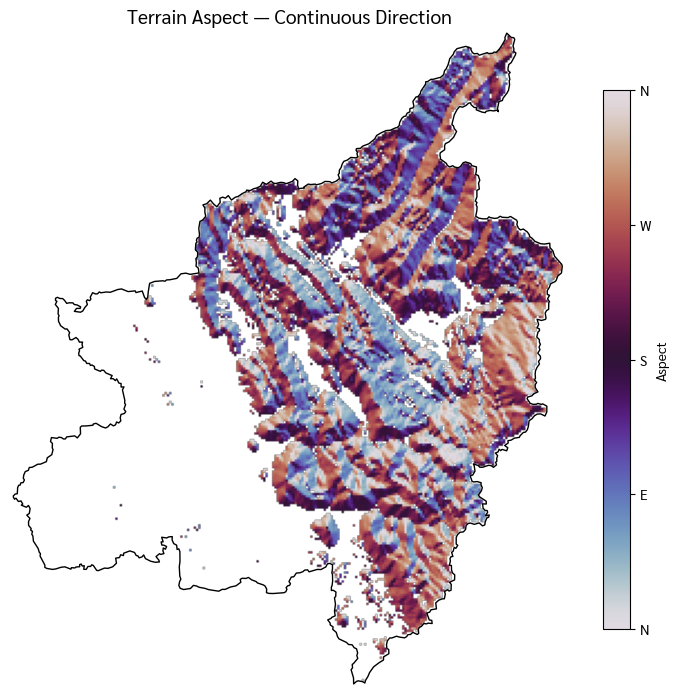

In [33]:
fig_aspect_cont, ax = plt.subplots(figsize=(9, 10))

im = ax.imshow(
    aspect_deg,
    extent=[
        utm_bounds[0],
        utm_bounds[2],
        utm_bounds[1],
        utm_bounds[3]
    ],
    origin="upper",
    cmap="twilight",
    vmin=0,
    vmax=360
)

phs_utm.boundary.plot(ax=ax, color="black", linewidth=1.0)

cbar = fig_aspect_cont.colorbar(
    im,
    ax=ax,
    shrink=0.7
)

cbar.set_label("Aspect")
cbar.set_ticks([0, 90, 180, 270, 360])
cbar.set_ticklabels(["N", "E", "S", "W", "N"])

ax.set_title(
    "Terrain Aspect — Continuous Direction",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

## 39. Convert aspect to 8 directions + Flat

In [34]:
aspect_class = np.full(
    dem_utm.shape,
    -9999,
    dtype="int16"
)

valid_aspect = np.isfinite(aspect_deg)

aspect_class[valid_aspect] = (
    (
        np.floor(
            (aspect_deg[valid_aspect] + 22.5)
            / 45.0
        ).astype(int)
        % 8
    )
    + 1
)

aspect_class[
    flat_mask & np.isfinite(dem_utm)
] = 0

aspect_labels = {
    0: "Flat",
    1: "N",
    2: "NE",
    3: "E",
    4: "SE",
    5: "S",
    6: "SW",
    7: "W",
    8: "NW"
}

rows = []

valid_terrain_count = np.isfinite(dem_utm).sum()

for class_code, label in aspect_labels.items():
    count = int((aspect_class == class_code).sum())

    rows.append({
        "class_code": class_code,
        "aspect_class": label,
        "pixel_count": count,
        "percent": 100 * count / valid_terrain_count
    })

aspect_stats = pd.DataFrame(rows)

display(aspect_stats.round(2))

,class_code,aspect_class,pixel_count,percent
0,0,Flat,13766,38.78
1,1,N,2092,5.89
2,2,NE,2659,7.49
3,3,E,2311,6.51
4,4,SE,2080,5.86
5,5,S,2233,6.29
6,6,SW,2799,7.89
7,7,W,3694,10.41
8,8,NW,2763,7.78


## 40. Plot categorical aspect map

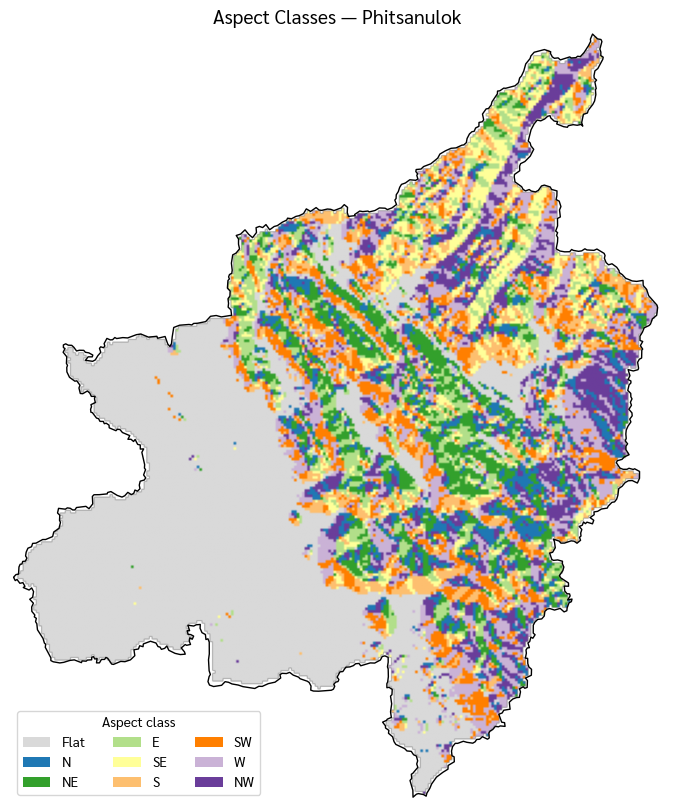

In [35]:
aspect_colors = [
    "#d9d9d9",
    "#1f78b4",
    "#33a02c",
    "#b2df8a",
    "#ffff99",
    "#fdbf6f",
    "#ff7f00",
    "#cab2d6",
    "#6a3d9a"
]

aspect_cmap = mpl.colors.ListedColormap(aspect_colors)

aspect_norm = BoundaryNorm(
    np.arange(-0.5, 9.5, 1),
    aspect_cmap.N
)

plot_aspect = np.where(
    aspect_class >= 0,
    aspect_class,
    np.nan
)

fig_aspect, ax = plt.subplots(figsize=(9, 10))

ax.imshow(
    plot_aspect,
    extent=[
        utm_bounds[0],
        utm_bounds[2],
        utm_bounds[1],
        utm_bounds[3]
    ],
    origin="upper",
    cmap=aspect_cmap,
    norm=aspect_norm
)

phs_utm.boundary.plot(ax=ax, color="black", linewidth=1.0)

handles = [
    Patch(
        facecolor=aspect_colors[k],
        label=aspect_labels[k]
    )
    for k in range(9)
]

ax.legend(
    handles=handles,
    title="Aspect class",
    loc="lower left",
    ncol=3
)

ax.set_title(
    "Aspect Classes — Phitsanulok",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

## 41. Aspect statistics: what should be reported?

สำหรับบทนี้รายงาน:

```text
Pixel count
Percentage
Dominant direction class
```

ไม่ใช้ arithmetic mean aspect เป็นสถิติหลัก

In [36]:
dominant_aspect = (
    aspect_stats
    .sort_values("pixel_count", ascending=False)
    .iloc[0]
)

print("Dominant aspect class:", dominant_aspect["aspect_class"])
print(f"Percentage: {dominant_aspect['percent']:.2f}%")

ASPECT_PATH = RASTER_DIR / "phitsanulok_aspect_deg.tif"

write_float_raster(
    ASPECT_PATH,
    aspect_deg,
    dst_transform,
    TARGET_CRS
)

Dominant aspect class: Flat
Percentage: 38.78%


# Part J — Slope Zonal Statistics by Tambon

## 42. Raster → Polygon

เป้าหมาย:

```text
Slope raster
+
Tambon polygons
↓
Mean / Median / Std / P90 / Pixel count
```

นี่เป็นการเชื่อม Raster GIS กลับเข้าสู่ Vector GIS

## 43. Load ADM3 and select Phitsanulok

In [37]:
ADM3_URL = (
    f"{BASE_GIS}/tambon_simplify/"
    "tha_admbnda_adm3_rtsd_20220121.zip"
)

adm3_shp = download_and_extract_zip(
    ADM3_URL,
    "tha_admbnda_adm3_rtsd_20220121.zip",
    "adm3"
)

tambon = gpd.read_file(adm3_shp, encoding="UTF-8")

T_ADM1 = find_column(
    tambon,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

T_ADM2 = find_column(
    tambon,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

T_ADM3 = find_column(
    tambon,
    ["ADM3_TH", "NAME_3_TH"],
    required=True
)

T_CODE = find_column(
    tambon,
    ["ADM3_PCODE", "ADM3_CODE"],
    required=True
)

phs_tambon_utm = (
    tambon[
        tambon[T_ADM1]
        .astype(str)
        .str.contains("พิษณุโลก", na=False)
    ]
    .copy()
    .to_crs(TARGET_CRS)
    .reset_index(drop=True)
)

print("Tambons :", len(phs_tambon_utm))
print("Districts:", phs_tambon_utm[T_ADM2].nunique())

Tambons : 93
Districts: 9


## 44. Extract raster values inside polygon

In [38]:
def extract_values_for_geometry(
    array,
    transform,
    geom
):
    inside = geometry_mask(
        [mapping(geom)],
        out_shape=array.shape,
        transform=transform,
        invert=True
    )

    return array[
        inside
        & np.isfinite(array)
    ]


def summarize_slope(polygons):
    records = []

    for idx, row in polygons.iterrows():
        values = extract_values_for_geometry(
            slope_deg,
            dst_transform,
            row.geometry
        )

        if len(values) == 0:
            stats = {
                "slope_mean": np.nan,
                "slope_median": np.nan,
                "slope_std": np.nan,
                "slope_p90": np.nan,
                "pixel_count": 0
            }
        else:
            stats = {
                "slope_mean": float(np.mean(values)),
                "slope_median": float(np.median(values)),
                "slope_std": float(np.std(values)),
                "slope_p90": float(np.percentile(values, 90)),
                "pixel_count": int(len(values))
            }

        stats["_row_index"] = idx
        records.append(stats)

    return pd.DataFrame(records).set_index("_row_index")

## 45. Calculate Tambon slope statistics

In [39]:
tambon_stats = summarize_slope(
    phs_tambon_utm
)

phs_tambon_slope = phs_tambon_utm.join(
    tambon_stats
)

display(
    phs_tambon_slope[
        [
            T_ADM2,
            T_ADM3,
            "slope_mean",
            "slope_median",
            "slope_std",
            "slope_p90",
            "pixel_count"
        ]
    ]
    .sort_values("slope_mean", ascending=False)
    .head(15)
    .round(2)
)

,ADM2_TH,ADM3_TH,slope_mean,slope_median,slope_std,slope_p90,pixel_count
35,ชาติตระการ,บ่อภาค,7.69,7.08,4.72,14.28,2027
24,นครไทย,นาบัว,7.53,6.95,4.96,13.98,516
26,นครไทย,น้ำกุ่ม,6.87,6.31,4.18,12.75,446
25,นครไทย,นครชุม,6.81,6.63,3.76,11.91,616
32,ชาติตระการ,ชาติตระการ,6.03,5.38,4.06,11.65,828
86,เนินมะปราง,ชมพู,5.77,5.03,4.35,12.36,1622
82,วังทอง,วังนกแอ่น,5.28,4.26,3.81,10.73,2215
27,นครไทย,ยางโกลน,5.20,4.84,3.39,9.82,504
28,นครไทย,บ่อโพธิ์,5.13,4.54,3.44,9.68,953
80,วังทอง,แก่งโสภา,4.71,2.78,5.27,13.93,441


## 46. Static choropleth: Mean slope

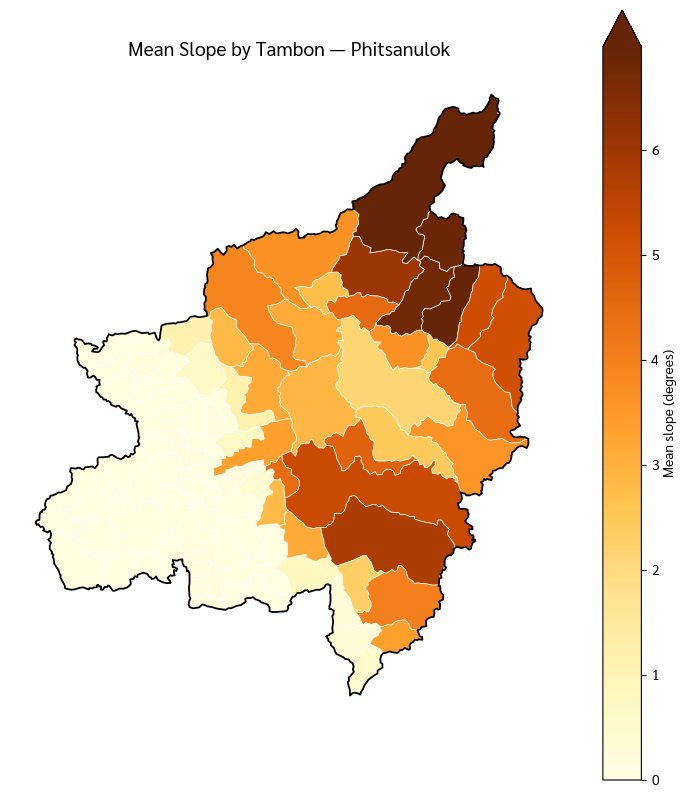

In [40]:
MEAN_SLOPE_VMAX = np.nanpercentile(
    phs_tambon_slope["slope_mean"],
    98
)

fig_tambon_slope, ax = plt.subplots(figsize=(9, 10))

phs_tambon_slope.plot(
    ax=ax,
    column="slope_mean",
    cmap="YlOrBr",
    vmin=0,
    vmax=MEAN_SLOPE_VMAX,
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={
        "label": "Mean slope (degrees)"
    }
)

phs_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.3
)

ax.set_title(
    "Mean Slope by Tambon — Phitsanulok",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()

plt.show()

# Part K — Folium: Mean / Median / P90 Slope

## 47. Interactive map design

Basemaps:

```text
OpenTopoMap
Esri World Topographic
Esri World Imagery
```

Operational layers:

```text
Mean slope
Median slope
P90 slope
```

## 48. Prepare compact GeoJSON

In [41]:
web_fields = [
    T_CODE,
    T_ADM2,
    T_ADM3,
    "slope_mean",
    "slope_median",
    "slope_p90",
    "pixel_count",
    "geometry"
]

tambon_web = (
    phs_tambon_slope[web_fields]
    .copy()
    .to_crs("EPSG:4326")
)

tambon_web[T_CODE] = tambon_web[T_CODE].astype(str)

for field in ["slope_mean", "slope_median", "slope_p90"]:
    tambon_web[field] = pd.to_numeric(
        tambon_web[field],
        errors="coerce"
    )

tambon_geojson = json.loads(tambon_web.to_json())

json.dumps(
    tambon_geojson,
    ensure_ascii=False
)

print("Tambon GeoJSON serialization OK")

Tambon GeoJSON serialization OK


## 49. Build shared Folium color scale

In [42]:
slope_fields = [
    "slope_mean",
    "slope_median",
    "slope_p90"
]

vals = tambon_web[
    slope_fields
].to_numpy(dtype=float).ravel()

vals = vals[np.isfinite(vals)]

WEB_SLOPE_MIN = 0.0
WEB_SLOPE_MAX = float(np.max(vals))

if np.isclose(WEB_SLOPE_MIN, WEB_SLOPE_MAX):
    WEB_SLOPE_MAX = WEB_SLOPE_MIN + 1.0

mpl_cmap = plt.get_cmap("YlOrBr")

web_colors = [
    mpl.colors.to_hex(mpl_cmap(v))
    for v in np.linspace(0.15, 0.95, 9)
]

slope_colormap = bcm.LinearColormap(
    colors=web_colors,
    vmin=WEB_SLOPE_MIN,
    vmax=WEB_SLOPE_MAX,
    caption="Slope statistic (degrees)"
)

## 50. Create Folium map

In [43]:
def add_basemap(m, provider, name, show=False):
    folium.TileLayer(
        tiles=provider.build_url(),
        attr=provider.html_attribution,
        name=name,
        overlay=False,
        control=True,
        show=show
    ).add_to(m)


phs_center_ll = (
    phs_utm
    .to_crs("EPSG:4326")
    .geometry
    .union_all()
    .centroid
)

m_slope = folium.Map(
    location=[
        phs_center_ll.y,
        phs_center_ll.x
    ],
    zoom_start=8,
    tiles=None,
    control_scale=True
)

add_basemap(
    m_slope,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m_slope,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m_slope,
    xyz.Esri.WorldImagery,
    "Esri World Imagery",
    show=False
)

## 51. Add Mean / Median / P90 layers

In [44]:
def make_slope_style(field_name):
    def style(feature):
        value = feature["properties"].get(field_name)

        if value is None:
            fill = "#d9d9d9"
        else:
            fill = slope_colormap(float(value))

        return {
            "fillColor": fill,
            "fillOpacity": 0.68,
            "color": "#ffffff",
            "weight": 0.7
        }

    return style


for field_name, layer_name, show in [
    ("slope_mean", "Mean slope", True),
    ("slope_median", "Median slope", False),
    ("slope_p90", "P90 slope", False)
]:
    folium.GeoJson(
        tambon_geojson,
        name=layer_name,
        show=show,
        style_function=make_slope_style(field_name),
        tooltip=folium.GeoJsonTooltip(
            fields=[
                T_ADM3,
                T_ADM2,
                "slope_mean",
                "slope_median",
                "slope_p90",
                "pixel_count"
            ],
            aliases=[
                "Tambon:",
                "District:",
                "Mean slope:",
                "Median slope:",
                "P90 slope:",
                "Raster cells:"
            ],
            localize=True
        )
    ).add_to(m_slope)

slope_colormap.add_to(m_slope)

folium.LayerControl(
    collapsed=False
).add_to(m_slope)

m_slope

# Part L — Compare Slope Distributions with Boxplots

## 52. Why select one District at a time?

การวางประมาณ 93 Tambons ใน boxplot เดียวอ่านยากมาก

ดังนั้นใช้ hierarchy:

```text
Province
↓
Select District
↓
Compare Tambons
```

## 53. Function: Tambon slope boxplot by District

In [45]:
def plot_tambon_slope_boxplot(
    district_name,
    max_pixels_per_tambon=3000
):
    subset = phs_tambon_slope[
        phs_tambon_slope[T_ADM2]
        .astype(str)
        .str.contains(
            district_name,
            na=False
        )
    ].copy()

    if subset.empty:
        raise ValueError(
            f"ไม่พบอำเภอ: {district_name}"
        )

    box_values = []
    box_labels = []

    for _, row in subset.iterrows():
        values = extract_values_for_geometry(
            slope_deg,
            dst_transform,
            row.geometry
        )

        if len(values) == 0:
            continue

        if len(values) > max_pixels_per_tambon:
            step = int(
                np.ceil(
                    len(values)
                    / max_pixels_per_tambon
                )
            )
            values = values[::step]

        box_values.append(values)
        box_labels.append(str(row[T_ADM3]))

    order = np.argsort([
        np.median(v)
        for v in box_values
    ])

    box_values = [box_values[i] for i in order]
    box_labels = [box_labels[i] for i in order]

    fig, ax = plt.subplots(
        figsize=(
            10,
            max(6, 0.45 * len(box_labels))
        )
    )

    ax.boxplot(
        box_values,
        vert=False,
        tick_labels=box_labels,
        showfliers=False
    )

    ax.set_title(
        f"Slope Distribution by Tambon — {district_name}"
    )
    ax.set_xlabel("Slope (degrees)")
    ax.set_ylabel("Tambon")
    ax.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

    return subset

## 54. Example: Mueang Phitsanulok

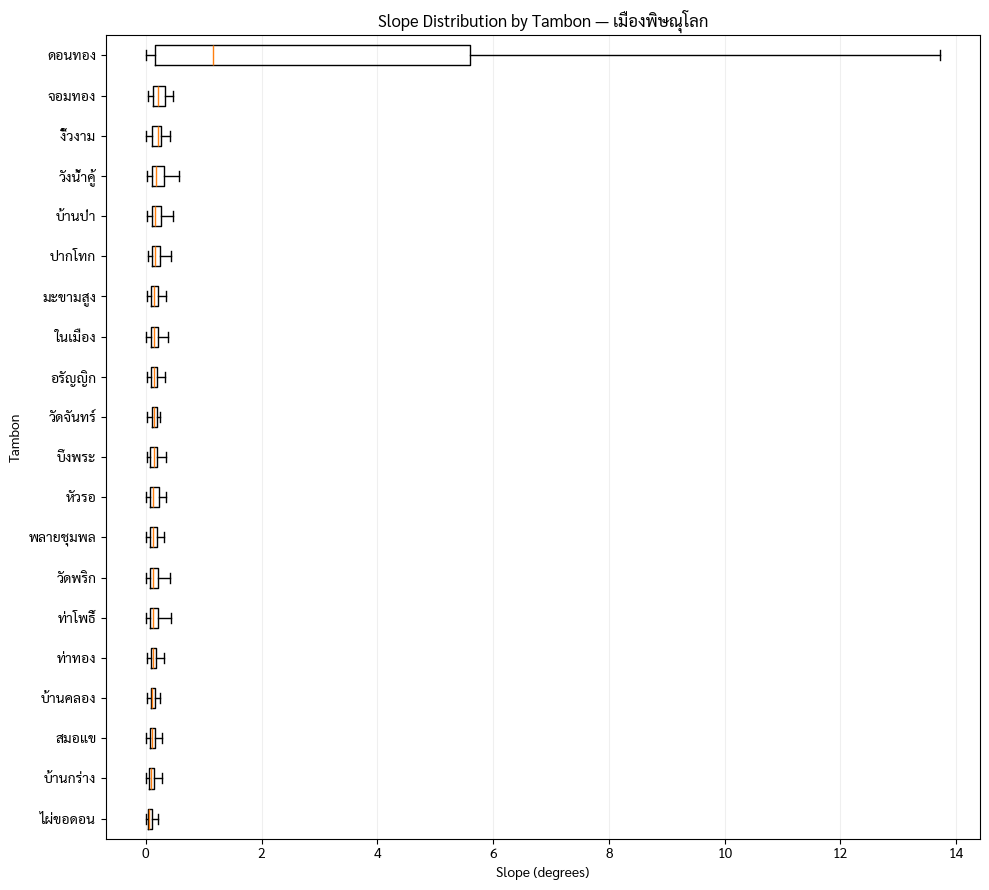

In [46]:
mueang_tambons = plot_tambon_slope_boxplot(
    "เมืองพิษณุโลก"
)

## 55. Boxplot interpretation

พิจารณา:

- median
- interquartile range
- distribution width
- differences among Tambons

Mean slope เพียงค่าเดียวไม่สามารถแทน terrain distribution ทั้งหมดได้

# Part M — Export

## 56. Export vectors, tables, HTML and figures

In [47]:
PROFILE_GPKG = VECTOR_DIR / "terrain_profiles.gpkg"

if PROFILE_GPKG.exists():
    PROFILE_GPKG.unlink()

profiles_gdf.to_file(
    PROFILE_GPKG,
    layer="profiles",
    driver="GPKG"
)

TAMBON_GPKG = VECTOR_DIR / "tambon_slope_statistics.gpkg"

if TAMBON_GPKG.exists():
    TAMBON_GPKG.unlink()

phs_tambon_slope.to_file(
    TAMBON_GPKG,
    layer="tambon_slope_stats",
    driver="GPKG"
)

dem_stats.to_csv(
    TABLE_DIR / "dem_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

phs_dem_stats.to_csv(
    TABLE_DIR / "phitsanulok_dem_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

profile_df.to_csv(
    TABLE_DIR / "profile_samples.csv",
    index=False,
    encoding="utf-8-sig"
)

slope_stats.to_csv(
    TABLE_DIR / "slope_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

aspect_stats.to_csv(
    TABLE_DIR / "aspect_class_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

phs_tambon_slope.drop(
    columns="geometry"
).to_csv(
    TABLE_DIR / "tambon_slope_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

m_slope.save(
    HTML_DIR / "phitsanulok_slope_zonal_stats.html"
)

figures = {
    "dem_overview_300dpi.png": fig_dem_overview,
    "phitsanulok_dem_300dpi.png": fig_phs_dem,
    "profile_directions_300dpi.png": fig_profile_map,
    "terrain_profiles_300dpi.png": fig_profiles,
    "slope_300dpi.png": fig_slope,
    "hillshade_300dpi.png": fig_hillshade,
    "dem_hillshade_300dpi.png": fig_dem_hs,
    "aspect_continuous_300dpi.png": fig_aspect_cont,
    "aspect_classes_300dpi.png": fig_aspect,
    "tambon_mean_slope_300dpi.png": fig_tambon_slope
}

for filename, fig in figures.items():
    fig.savefig(
        MAP_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

print("Exports complete.")

Exports complete.


## 57. Inspect outputs

In [48]:
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(
            p.relative_to(OUTPUT_DIR),
            f"({p.stat().st_size / 1024:,.1f} KB)"
        )

html/phitsanulok_slope_zonal_stats.html (588.8 KB)
maps/aspect_classes_300dpi.png (261.6 KB)
maps/aspect_continuous_300dpi.png (285.1 KB)
maps/dem_hillshade_300dpi.png (296.2 KB)
maps/dem_overview_300dpi.png (1,561.9 KB)
maps/hillshade_300dpi.png (252.0 KB)
maps/phitsanulok_dem_300dpi.png (322.8 KB)
maps/profile_directions_300dpi.png (302.5 KB)
maps/slope_300dpi.png (298.1 KB)
maps/tambon_mean_slope_300dpi.png (412.1 KB)
maps/terrain_profiles_300dpi.png (405.4 KB)
rasters/phitsanulok_aspect_deg.tif (78.4 KB)
rasters/phitsanulok_dem_original_crs.tif (51.9 KB)
rasters/phitsanulok_dem_utm47n.tif (127.1 KB)
rasters/phitsanulok_hillshade.tif (113.1 KB)
rasters/phitsanulok_slope_deg.tif (127.6 KB)
tables/aspect_class_statistics.csv (0.3 KB)
tables/dem_statistics.csv (0.1 KB)
tables/phitsanulok_dem_statistics.csv (0.2 KB)
tables/profile_samples.csv (28.5 KB)
tables/slope_statistics.csv (0.2 KB)
tables/tambon_slope_statistics.csv (28.7 KB)
vectors/tambon_slope_statistics.gpkg (208.0 KB)
vector

# Part N — Concept Check & Exercises

## 58. Concept Check

1. DEM pixel value หมายถึงอะไร?
2. ทำไมต้องตรวจ CRS / pixel size / NoData ก่อนวิเคราะห์?
3. NoData ต่างจาก elevation = 0 อย่างไร?
4. ทำไม display range จึงไม่จำเป็นต้องเท่ากับ actual range?
5. ทำไมต้องใช้ projected CRS ก่อน slope?
6. Centroid ใน profile analysis หมายถึงอะไร?
7. Slope ต่างจาก elevation อย่างไร?
8. Hillshade เป็น elevation หรือไม่?
9. ทำไม aspect เป็น circular variable?
10. Zonal statistics เชื่อม raster กับ polygon อย่างไร?
11. Mean slope และ slope distribution ให้ข้อมูลเหมือนกันหรือไม่?

## 59. Exercise 1 — Change Hillshade Illumination

คำนวณ hillshade ใหม่โดยใช้ azimuth:

```text
45°
135°
225°
315°
```

ให้ altitude = 45° คงที่

อภิปรายว่า relief perception เปลี่ยนอย่างไร ทั้งที่ DEM ไม่เปลี่ยน

## 60. Exercise 2 — Highest-slope Tambons

เปรียบเทียบ Top 10 จาก

```text
slope_mean
```

กับ

```text
slope_p90
```

ถามว่า ranking เหมือนกันหรือไม่ และเพราะอะไร

## 61. Exercise 3 — Another District Boxplot

เรียก

```python
plot_tambon_slope_boxplot("ชื่ออำเภอ")
```

กับอำเภออื่นในพิษณุโลก

แล้วเปรียบเทียบ terrain variability ระหว่างตำบล

## 62. Exercise 4 — N–S vs E–W Profiles

ใช้ `profile_df` เปรียบเทียบ

```text
N vs S
E vs W
```

แล้วอธิบายว่า profile สอดคล้องกับ DEM และ hillshade อย่างไร

## 63. MSc Challenge — DEM Resolution Sensitivity

Resample DEM ให้หยาบขึ้น:

```text
Original
2× coarser
4× coarser
```

คำนวณ slope ใหม่และเปรียบเทียบ:

$$
Mean,\ Median,\ P90
$$

คำถาม:

> DEM resolution ส่งผลต่อ slope distribution อย่างไร?

เชื่อมกับ Notebook 09:

$$
\boxed{
Spatial\ Resolution
\rightarrow
Analytical\ Result
}
$$

# Summary

Notebook 10 แสดง workflow:

$$
\boxed{
Elevation
\rightarrow
Terrain\ Derivatives
\rightarrow
Terrain\ Statistics
\rightarrow
Administrative\ Interpretation
}
$$

สิ่งที่ต้องจำ:

> **DEM value = elevation, not terrain shape by itself**

> **Inspect CRS, pixel size, bounds and NoData before analysis**

> **Horizontal and vertical units must be compatible for slope**

> **Centroid ≠ city center**

> **Hillshade is visualization, not elevation**

> **Aspect is circular data**

> **Raster → Zonal statistics → Polygon bridges raster and vector GIS**

> **Mean terrain value does not replace the full terrain distribution**